In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import sklearn
import os

[0.1030909090909091, 0.2210909090909091, 0.3201818181818182, 0.24963636363636363, 0.4709090909090909, 0.5849090909090909, 0.6298181818181818, 0.7094545454545454]


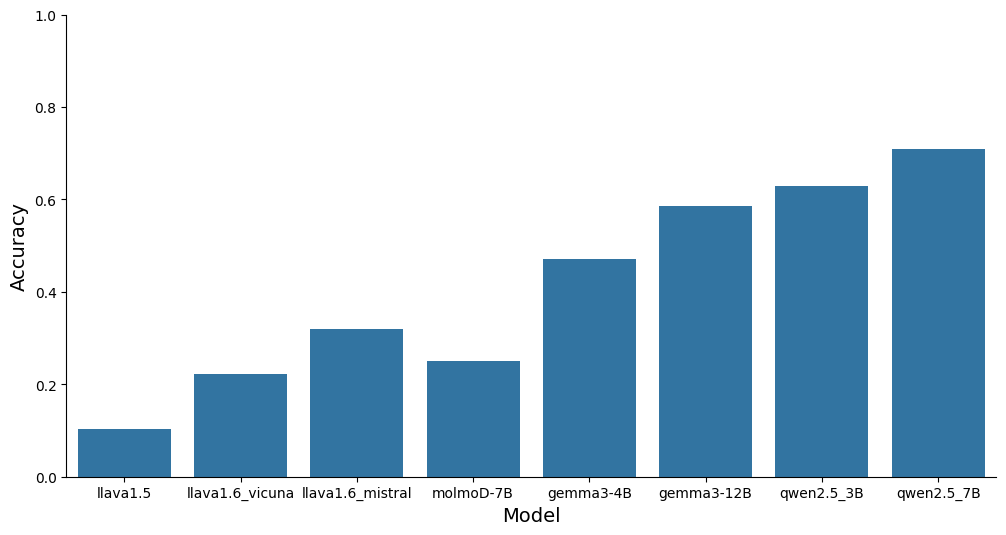

In [15]:
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'molmoD-7B', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
path = f'./results/'

acc_ls = []
for model in model_ls:
    files = os.listdir(f'{path}/{model}')
    for file in files:
        if '.csv' in file:
            prediction_df = pd.read_csv(f'{path}/{model}/{file}')

    if model=='llava1.5':
        acc_ls = acc_ls + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_lower']])/len(prediction_df)]
        
    else:
        acc_ls = acc_ls + [len(prediction_df[prediction_df['prediction_lower']==prediction_df['gold_reference_formatted']])/len(prediction_df)]

print(acc_ls)
fig,ax = plt.subplots(1,1,figsize=(12,6))


# acc_ls = [0.1, 0.22, 0.32, 0.47, 0.58, 0.63, 0.71]
b = sns.barplot(data=pd.DataFrame({'Model':model_ls, 'Accuracy':acc_ls}), 
                                x='Model', y='Accuracy',ax=ax)
b.set_xlabel(b.get_xlabel(), fontsize=14)
b.set_ylabel(b.get_ylabel(), fontsize=14)
b.set(ylim=(0, 1))
sns.despine(top=True, right=True)